# 视觉语言模型（VLM）

> **前情回顾**：上一 Part 我们看过 CoT 和 Thinking 模型，重点是让 LLM 在文字里更会推理。
> **本 Part 目标**：今天换一个问题：图片不是文字，LLM 为什么也能“看图说话”？

你可以先把困惑说成一句话：LLM 只会处理 token，可图片是一堆像素。那一张猫的照片，怎么变成 LLM 能读懂的 token 呢？

**Vision-Language Model（VLM）**，中文可以叫视觉语言模型。这里讨论的是聊天式 VLM：输入可以包含图片和文字，输出主要是文字。更广义的 VLM 还包括图文检索、caption、VQA、多图/视频理解等任务。比如你给它一张菜单照片，再问“最便宜的饮料是什么？”，它需要先看图，再用语言回答。

这一节我们不调用现成模型，而是从零搭一个极简版 VLM。路径很清楚：

1. 先把图片切成小块，也就是 patch。
2. 再把每个 patch 变成向量，也就是视觉 token。
3. 最后把视觉 token 和文本 token 拼在一起，送进 Transformer。

听起来像“给 LLM 装一双眼睛”，但这双眼睛不是直接看像素，而是先把像素翻译成 LLM 熟悉的 embedding。


## 1. LLM 为什么不能直接读图片？

先定义两个词。

**Token** 是模型一次处理的最小单位。文本里，一个 token 可能是一个字、一个词，或者一个词的一部分。比如“猫坐下”可能被 tokenizer 变成几个整数 ID。

**Embedding** 是 token 的向量表示。比如 token id `12` 本身只是编号，模型真正计算时会把它查表变成 `[0.3, -0.1, ...]` 这样的向量。

问题来了：图片不是一串 token，而是一个二维像素网格。

```
文字: "一只猫坐在垫子上"
  -> Tokenizer -> [12, 45, 78, 3, 90, 23]
  -> Embedding -> [6 个向量]

图片: 224 x 224 像素的猫照片
  -> ???       -> LLM 现在还不知道怎么处理
```

所以 VLM 的第一性问题是：**怎么把图片也变成一串 embedding？**

最朴素的答案是：把图片切成很多小块，每个小块当成一个“视觉单词”。这样图片就从二维网格变成了一维序列。


## 2. Patchify：先把图片切成小块

**Patchify** 的意思是“把图片切成 patch”。Patch 就是一小块图片。

比如一张 224 x 224 的图片，如果每个 patch 是 16 x 16，那么横向有 14 块，纵向也有 14 块，所以一共有 14 x 14 = 196 个 patch。这个设置来自 ViT 里的经典例子；真实 VLM 也常用 14、16、32、336 分辨率、多裁剪或动态分辨率。参考：[ViT](https://arxiv.org/abs/2010.11929)。

```
原始图片: 224 x 224 像素
patch 大小: 16 x 16

224 / 16 = 14
14 x 14 = 196 个 patch

┌──┬──┬──┬──┐
│  │  │  │  │
├──┼──┼──┼──┤
│  │猫│  │  │  <- 猫脸可能落在其中几个 patch 里
├──┼──┼──┼──┤
│  │  │  │  │
└──┴──┴──┴──┘
```

为什么不直接把整张图变成一个 token？因为一个 token 太粗了，模型很难知道猫脸、文字、背景分别在哪里。切成 patch 以后，模型至少保留了“局部区域”的信息。

下面先不用任何视觉模型，只用 `unfold` 手动看一下切块后的 shape。


In [1]:
# 先手算 shape，再用代码验证 patchify
import torch
import torch.nn as nn

torch.manual_seed(42)

IMG_SIZE = 224
PATCH_SIZE = 16

# 模拟一张 RGB 图片: [颜色通道, 高度, 宽度]
fake_image = torch.randn(3, IMG_SIZE, IMG_SIZE)

print("原始图片 shape:", fake_image.shape)
print("解释: 3 个颜色通道，每个通道是一张 224 x 224 的表格")

# unfold 会沿着高度、宽度切窗口。stride=16 表示窗口之间不重叠。
patches = fake_image.unfold(1, PATCH_SIZE, PATCH_SIZE)
patches = patches.unfold(2, PATCH_SIZE, PATCH_SIZE)

print("\n切块后 shape:", patches.shape)
print("解释: [3通道, 14行patch, 14列patch, 16高, 16宽]")

num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
patch_dim = 3 * PATCH_SIZE * PATCH_SIZE
patches_flat = patches.permute(1, 2, 0, 3, 4).reshape(num_patches, patch_dim)

print("\n展平后 shape:", patches_flat.shape)
print(f"关键观察: 一张图变成了 {num_patches} 个 patch")
print(f"每个 patch 有 {patch_dim} 个数字，也就是 3 x 16 x 16")


原始图片 shape: torch.Size([3, 224, 224])
解释: 3 个颜色通道，每个通道是一张 224 x 224 的表格

切块后 shape: torch.Size([3, 14, 14, 16, 16])
解释: [3通道, 14行patch, 14列patch, 16高, 16宽]

展平后 shape: torch.Size([196, 768])
关键观察: 一张图变成了 196 个 patch
每个 patch 有 768 个数字，也就是 3 x 16 x 16


## 3. Patch Embedding：再把小块变成向量

现在每个 patch 有 768 个数字，因为 $3 \times 16 \times 16 = 768$。

但 LLM 里每个文本 token 的 embedding 通常是固定维度，比如 512、768 或 4096。视觉 patch 如果也想混进 LLM，就必须变成同样维度的向量。

这个步骤叫 **Patch Embedding**：把一个 patch 里的像素数字，投影成一个 `d_model` 维向量。

```
一个 patch:      768 个像素数字
Patch Embedding: Linear(768 -> d_model)
输出:            1 个视觉 token，维度是 d_model

文本 token:      Embedding 查表 -> 1 个文本 token，维度也是 d_model

维度一样，后面才可以拼接。
```

实际 ViT 里经常用 `Conv2d(kernel_size=patch_size, stride=patch_size)` 一步完成“切块 + 线性投影”。这里重点不是 CNN 那种多层边缘/纹理提取，而是用卷积写法高效实现“每个 patch 共享同一个线性投影”。


In [1]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """把图片切成 patch，并把每个 patch 映射成一个视觉 token。"""
    def __init__(self, img_size=224, patch_size=16, in_channels=3, d_model=512):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # kernel_size=patch_size: 每次看一个 patch
        # stride=patch_size: 下一个窗口刚好跳到下一个 patch
        self.proj = nn.Conv2d(
            in_channels,
            d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        """
        参数:
            x: [batch, 3, 224, 224] 的图片
        返回:
            [batch, num_patches, d_model] 的视觉 token
        """
        x = self.proj(x)      # [batch, d_model, 14, 14]
        x = x.flatten(2)      # [batch, d_model, 196]
        x = x.transpose(1, 2) # [batch, 196, d_model]
        return x

patch_emb = PatchEmbedding(img_size=224, patch_size=16, d_model=512)
dummy_img = torch.randn(2, 3, 224, 224)
visual_tokens = patch_emb(dummy_img)

print("输入图片:", dummy_img.shape)
print("视觉 token:", visual_tokens.shape)
print("关键观察: batch 里每张图都有 196 个视觉 token，每个 token 是 512 维")


输入图片: torch.Size([2, 3, 224, 224])
视觉 token: torch.Size([2, 196, 512])
关键观察: batch 里每张图都有 196 个视觉 token，每个 token 是 512 维


## 4. 视觉 token 怎么和文本 token 融合？

到这里，图片已经变成了 `[batch, 196, d_model]`。文本也会通过 embedding 变成 `[batch, text_len, d_model]`。

既然最后一维都是 `d_model`，最简单的融合方式就是：**沿着序列长度这一维拼接**。

```
视觉 token: [vis_1] [vis_2] ... [vis_196]
文本 token: [请] [描述] [这] [张] [图]

拼接后:
[vis_1] [vis_2] ... [vis_196] [请] [描述] [这] [张] [图]
```

这就是 LLaVA 这类 Visual Token 方案的直觉：从张量形状看，LLM 接到的是一串 embedding；但工程上通常会用 `<image>` 占位符、特殊 token 或固定插入位置，让 tokenizer/template 和模型都知道哪里应该替换成视觉特征。


In [1]:
# 模拟视觉 token 和文本 token 拼接
import torch
import torch.nn as nn

d_model = 512
text_vocab_size = 1000

# 假设 tokenizer 把“请描述这张图”变成 5 个 id
text_ids = torch.tensor([[5, 12, 78, 3, 90]])
text_embedding = nn.Embedding(text_vocab_size, d_model)
text_tokens = text_embedding(text_ids)

visual_tokens = torch.randn(1, 196, d_model)
combined = torch.cat([visual_tokens, text_tokens], dim=1)

print("视觉 token:", visual_tokens.shape)
print("文本 token:", text_tokens.shape)
print("拼接后:", combined.shape)
print("关键观察: 196 个图片 token + 5 个文本 token = 201 个 token")


视觉 token: torch.Size([1, 196, 512])
文本 token: torch.Size([1, 5, 512])
拼接后: torch.Size([1, 201, 512])
关键观察: 196 个图片 token + 5 个文本 token = 201 个 token


## 5. 还差一个 Projector：把视觉空间翻译到语言空间

刚才的 `PatchEmbedding` 是教学版，直接把像素投影到了 `d_model`。真实 VLM 通常多一步：

1. Vision Encoder 先把图片编码成视觉特征。
2. Projector 再把视觉特征映射到 LLM 的 embedding 空间。

为什么要 Projector？因为 Vision Encoder 和 LLM 是两个模型，它们的向量空间不天然一致。

打个比方：Vision Encoder 说的是“视觉方言”，LLM 说的是“语言方言”。Projector 就像翻译器，把视觉特征翻译成 LLM 能接住的 embedding。

```
图片 -> Vision Encoder -> 视觉特征 [B, 196, d_vis]
                     -> Projector -> 语言空间 [B, 196, d_llm]
文本 -> Token Embedding -----------------------> [B, T, d_llm]

最后拼接: [B, 196 + T, d_llm]
```

LLaVA 早期使用线性层连接 CLIP vision encoder 和 LLM；LLaVA-1.5 常用两层 MLP connector。其他 VLM 可能使用 Q-Former、Perceiver Resampler、cross-attention 或更复杂的 projector。参考：[LLaVA](https://arxiv.org/abs/2304.08485)、[LLaVA-1.5](https://openaccess.thecvf.com/content/CVPR2024/papers/Liu_Improved_Baselines_with_Visual_Instruction_Tuning_CVPR_2024_paper.pdf)。


In [1]:
import torch
import torch.nn as nn

class LLaVAProjector(nn.Module):
    """把视觉特征映射到 LLM 的 embedding 空间。"""
    def __init__(self, vis_dim=1024, llm_dim=4096):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(vis_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )

    def forward(self, visual_features):
        """
        参数:
            visual_features: [batch, num_patches, vis_dim]
        返回:
            [batch, num_patches, llm_dim]
        """
        return self.mlp(visual_features)

projector = LLaVAProjector(vis_dim=1024, llm_dim=4096)
vision_features = torch.randn(2, 196, 1024)
llm_space_features = projector(vision_features)

print("Vision Encoder 输出:", vision_features.shape)
print("Projector 输出:", llm_space_features.shape)
print("关键观察: patch 数量没变，只是每个 token 的维度对齐到了 LLM")


Vision Encoder 输出: torch.Size([2, 196, 1024])
Projector 输出: torch.Size([2, 196, 4096])
关键观察: patch 数量没变，只是每个 token 的维度对齐到了 LLM


## 6. 三种主流 VLM 架构

现在你已经懂了最朴素的 Visual Token 路线。为了教学，可以先把常见方案压缩成三类；真实模型经常混合使用这些方法。

| 方案 | 图片怎么进 LLM | LLM 结构要改吗 | 代表模型 |
|:---|:---|:---:|:---|
| Visual Token | 图片 token 直接拼进序列 | 不需要 | LLaVA |
| Cross-Attention | 文本 token 去查询视觉特征 | 需要 | Flamingo |
| Q-Former | 用少量 query 压缩视觉特征 | 通常不需要 | BLIP-2 |

### 6.1 Visual Token：最直观

图片变成 196 个 token，直接放到文本前面。优点是 LLM 主体不用改，工程上最快。缺点也明显：序列变长，attention 计算更贵。

### 6.2 Cross-Attention：让文本主动“看图”

Self-Attention 是序列内部互相看：Q、K、V 都来自同一个序列。

Cross-Attention 是文本去看图片：Q 来自文本，K 和 V 来自视觉特征。

公式只差在 K、V 的来源：

$$
\text{CrossAttn}(X_{text}, X_{vis}) =
\text{softmax}\left(\frac{Q_{text}K_{vis}^T}{\sqrt{d_k}}\right)V_{vis}
$$

Flamingo 先用 Perceiver Resampler 把视觉输入变成固定数量的 visual latents，再在语言模型层中插入 gated cross-attention，让文本 hidden state 查询这些视觉 latents。门控残差让新增视觉分支可以从接近原语言模型行为的状态开始学习。参考：[Flamingo](https://arxiv.org/abs/2204.14198)。

### 6.3 Q-Former：先压缩再交给 LLM

Q-Former 的目标是减少视觉 token 数。比如 BLIP-2 论文实验中常用 32 个 learnable query，把 image encoder 的输出抽取成少量视觉表示。这样通常能减少交给 LLM 的视觉 token，但 query 数不是理论固定值，速度和效果都要看具体模型。参考：[BLIP-2](https://arxiv.org/abs/2301.12597)。

下面用代码对比 Visual Token 和 Cross-Attention 的计算量直觉。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossAttention(nn.Module):
    """Cross-Attention: Q 来自文本，K/V 来自图像。"""
    def __init__(self, d_model=512, n_heads=8):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, text_hidden, image_features):
        """
        参数:
            text_hidden: [batch, text_len, d_model]
            image_features: [batch, num_visual, d_model]
        返回:
            [batch, text_len, d_model]
        """
        batch, text_len, d_model = text_hidden.shape
        num_visual = image_features.shape[1]

        query = self.q_proj(text_hidden)
        key = self.k_proj(image_features)
        value = self.v_proj(image_features)

        query = query.view(batch, text_len, self.n_heads, self.head_dim)
        query = query.transpose(1, 2)
        key = key.view(batch, num_visual, self.n_heads, self.head_dim)
        key = key.transpose(1, 2)
        value = value.view(batch, num_visual, self.n_heads, self.head_dim)
        value = value.transpose(1, 2)

        scores = (query @ key.transpose(-2, -1)) * self.scale
        weights = F.softmax(scores, dim=-1)
        out = weights @ value
        out = out.transpose(1, 2).reshape(batch, text_len, d_model)
        return self.out_proj(out)

class GatedCrossAttentionBlock(nn.Module):
    """带 tanh 门控的 Cross-Attention 小模块。"""
    def __init__(self, d_model=512, n_heads=8):
        super().__init__()
        self.cross_attn = CrossAttention(d_model, n_heads)
        self.norm = nn.LayerNorm(d_model)
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, text_hidden, image_features):
        gate = torch.tanh(self.alpha)
        x = text_hidden + gate * self.cross_attn(text_hidden, image_features)
        return self.norm(x)

batch = 1
text_len = 50
num_visual = 196
d_model = 512

text_hidden = torch.randn(batch, text_len, d_model)
image_features = torch.randn(batch, num_visual, d_model)

visual_token_len = text_len + num_visual
visual_token_cost = visual_token_len ** 2
cross_attn_cost = text_len ** 2 + text_len * num_visual

block = GatedCrossAttentionBlock(d_model=d_model, n_heads=8)
out = block(text_hidden, image_features)

print("Visual Token 序列长度:", visual_token_len)
print("Visual Token attention 近似成本:", visual_token_cost)
print("Cross-Attention 输出 shape:", out.shape)
print("Cross-Attention 近似成本:", cross_attn_cost)
print("门控初始值 tanh(alpha):", torch.tanh(block.alpha).item())
print("关键观察: Cross-Attention 不拉长文本序列，但需要改 LLM 结构")


Visual Token 序列长度: 246
Visual Token attention 近似成本: 60516
Cross-Attention 输出 shape: torch.Size([1, 50, 512])
Cross-Attention 近似成本: 12300
门控初始值 tanh(alpha): 0.0
关键观察: Cross-Attention 不拉长文本序列，但需要改 LLM 结构


## 7. 图片为什么很“贵”？

一张 224 x 224 的图片，切成 16 x 16 patch 后是 196 个视觉 token。

一句“请描述这张图”可能只有几个 token。在短 prompt + 单图问答里，视觉 token 往往比文字 token 多；但长文本、多轮对话、视频、多图场景下，成本瓶颈会随输入形式变化。

这会带来两个后果：

1. 推理更慢，因为 attention 复杂度近似是 $O(n^2)$。
2. 多图更贵，因为每张图都可能带来几百个视觉 token。

那能不能减少视觉 token？可以，但通常会牺牲一部分空间细节，尤其是小字、密集物体和图表；好的 resampler、动态裁剪、多尺度策略可以尽量保留任务相关信息。


In [1]:
# 直观感受: patch 越大，视觉 token 越少
for patch_size in [8, 14, 16, 32]:
    tokens_per_side = 224 // patch_size
    num_tokens = tokens_per_side ** 2
    print(f"patch_size={patch_size:2d}: {tokens_per_side:2d} x {tokens_per_side:2d}",
          f"= {num_tokens:4d} 个视觉 token")

print("\n关键观察: patch=32 只有 49 个 token，但细节会更粗")
print("关键观察: patch=8 有 784 个 token，细节更多，但推理更慢")


patch_size= 8: 28 x 28 =  784 个视觉 token
patch_size=14: 16 x 16 =  256 个视觉 token
patch_size=16: 14 x 14 =  196 个视觉 token
patch_size=32:  7 x  7 =   49 个视觉 token

关键观察: patch=32 只有 49 个 token，但细节会更粗
关键观察: patch=8 有 784 个 token，细节更多，但推理更慢


## 8. 训练 VLM：为什么要冻结？

LLaVA / BLIP-2 这类复用预训练视觉塔和 LLM 的路线，通常不是从零训练三个大模块。它会复用已经训练好的 Vision Encoder 和 LLM，然后重点训练中间的连接部分。

先看三个组件：

```
Vision Encoder: 已经预训练好的视觉模型，比如 CLIP ViT、SigLIP、EVA-CLIP；ViT 是常用架构，不等于某个具体预训练模型
Projector:      从零开始，负责把视觉特征翻译到 LLM 空间
LLM:            已经会说话、推理、生成文本
```

为什么不全部一起训练？

- 参数太多，显存成本高。
- 数据不够，容易破坏原来会看图、会说话的能力。
- Projector 才是最需要从零学习的连接器。

所以经典 LLaVA 风格通常是两阶段。注意，“冻结 Vision Encoder”是 LLaVA 路线里的常见工程选择，不是所有 VLM 的永恒规则；如果数据和算力足够，也可以微调视觉塔或做多阶段解冻。

| 阶段 | 训练谁 | 冻结谁 | 目标 |
|:---|:---|:---|:---|
| 阶段 1：对齐训练 | Projector | Vision Encoder + LLM | 让视觉特征像 LLM embedding |
| 阶段 2：指令微调 | Projector + LLM | Vision Encoder | 学会看图回答问题 |

这里的“冻结”就是把参数的 `requires_grad` 设成 `False`。参数还参与前向计算，但不会被梯度更新。


In [1]:
# 用三个小模块模拟 VLM 的冻结策略
import torch.nn as nn

vision_encoder = nn.Linear(1024, 1024)
projector = LLaVAProjector(vis_dim=1024, llm_dim=4096)
llm_head = nn.Linear(4096, 1000)

def set_trainable(module, trainable):
    """把一个模块设置为可训练或冻结。"""
    for param in module.parameters():
        param.requires_grad = trainable

def count_trainable(module):
    """统计模块里可训练参数的数量。"""
    return sum(param.numel() for param in module.parameters() if param.requires_grad)

def show_stage(stage):
    """展示某个训练阶段的冻结结果。"""
    if stage == 1:
        set_trainable(vision_encoder, False)
        set_trainable(projector, True)
        set_trainable(llm_head, False)
    else:
        set_trainable(vision_encoder, False)
        set_trainable(projector, True)
        set_trainable(llm_head, True)

    print(f"阶段 {stage}")
    print("  Vision Encoder 可训参数:", count_trainable(vision_encoder))
    print("  Projector 可训参数:     ", count_trainable(projector))
    print("  LLM Head 可训参数:      ", count_trainable(llm_head))

show_stage(1)
print()
show_stage(2)
print("\n关键观察: Vision Encoder 两个阶段都冻结，Projector 两个阶段都训练")


阶段 1
  Vision Encoder 可训参数: 0
  Projector 可训参数:      20979712
  LLM Head 可训参数:       0

阶段 2
  Vision Encoder 可训参数: 0
  Projector 可训参数:      20979712
  LLM Head 可训参数:       4097000

关键观察: Vision Encoder 两个阶段都冻结，Projector 两个阶段都训练


## 9. 工程细节：特殊 token、位置编码、多分辨率

前面的主线已经够你搭出一个极简 VLM。但真实模型还会遇到几个工程问题。

**问题 1：LLM 怎么知道图片从哪里开始？**

有些模型会用特殊 token 包住视觉内容：

```
<image_start> [vis_1] [vis_2] ... [vis_196] <image_end> 请描述这张图
```

LLaVA 早期路线可以简单地把视觉 token 固定放在前面；多图、多轮对话时，特殊 token 会更清楚。

**问题 2：视觉 token 用什么位置编码？**

图片本来是二维的，但拼进 LLM 后会变成一维序列。最简单的做法是按从左到右、从上到下编号：

```
第 0 行: patch 0, patch 1, ..., patch 13
第 1 行: patch 14, patch 15, ..., patch 27
```

这能作为简化做法，但会弱化二维空间结构；真实模型常用 2D 位置编码、多尺度或动态分辨率策略。更复杂的模型会引入 2D 位置编码或动态分辨率策略。

**问题 3：高清图片怎么办？**

如果把 4K 图片强行缩到 224 x 224，小字和细节会丢。LLaVA-NeXT / LLaVA-1.6 这类路线使用 AnyRes 思路：先保留全局缩略图，再把高分辨率图片切成多个局部区域分别编码。代价是视觉 token 数会明显增加。


## 10. 极简 VLM 实现

现在把前面的组件串起来。这个版本非常小，但数据流是完整的：

1. `PatchEmbedding` 把图片变成视觉 token。
2. `text_embedding` 把文本 id 变成文本 token。
3. `torch.cat` 把两种 token 拼成一个序列。
4. `TransformerEncoder` 处理整个序列。
5. `lm_head` 输出每个位置的 token 分布；这个 MiniVLM 只演示数据流，不是严格的 GPT 式生成器。

它不是一个真正可对话的 VLM，因为我们没有训练它，也没有接真实 tokenizer；同时这里用的是 `TransformerEncoder`，默认双向 attention，不是带 causal mask 的 autoregressive decoder。但它可以帮你确认：VLM 的核心不是魔法，而是一条很普通的张量流水线。


In [1]:
import torch
import torch.nn as nn

class MiniVLM(nn.Module):
    """极简 Visual Token VLM。"""
    def __init__(self, text_vocab_size=100, d_model=128, num_heads=2, num_layers=2):
        super().__init__()
        self.vision = PatchEmbedding(
            img_size=224,
            patch_size=16,
            in_channels=3,
            d_model=d_model,
        )
        self.text_embedding = nn.Embedding(text_vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=4 * d_model,
            batch_first=True,
        )
        self.layers = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, text_vocab_size)

    def forward(self, images, text_ids):
        """
        参数:
            images: [batch, 3, 224, 224]
            text_ids: [batch, text_len]
        返回:
            [batch, 196 + text_len, vocab_size]
        """
        visual_tokens = self.vision(images)
        text_tokens = self.text_embedding(text_ids)
        tokens = torch.cat([visual_tokens, text_tokens], dim=1)
        hidden = self.layers(tokens)
        hidden = self.norm(hidden)
        return self.lm_head(hidden)

vlm = MiniVLM(text_vocab_size=100, d_model=128, num_heads=2, num_layers=2)

dummy_images = torch.randn(1, 3, 224, 224)
dummy_text = torch.randint(0, 100, (1, 10))
logits = vlm(dummy_images, dummy_text)

print("输入图片:", dummy_images.shape)
print("输入文本:", dummy_text.shape)
print("输出 logits:", logits.shape)
print("关键观察: 196 个视觉位置 + 10 个文本位置 = 206 个输出位置")
print("总参数量:", f"{sum(param.numel() for param in vlm.parameters()):,}")


输入图片: torch.Size([1, 3, 224, 224])
输入文本: torch.Size([1, 10])
输出 logits: torch.Size([1, 206, 100])
关键观察: 196 个视觉位置 + 10 个文本位置 = 206 个输出位置
总参数量: 520,932


## 11. CLIP：让视觉和文本住进同一个空间

前面几节把 VLM 的骨架搭好了：PatchEmbedding 切图、Projector 翻译、MiniVLM 拼接。但有个根本问题一直没回答：**视觉特征和文本特征一开始根本不在同一个空间里**——一张红圆图的向量，和「红圆」这两个词的向量，离得十万八千里。Projector 只是个线性层，它怎么知道该往哪个方向翻译？

答案要先于 VLM 出现：**CLIP**（Radford et al. 2021）。CLIP 用对比学习，把图像和文本强行拉进同一个空间——匹配的图文对靠近，不匹配的远离。训练完的图像编码器（ViT）就成了后来几乎所有 VLM 的视觉前端：LLaVA、Qwen-VL 都是用预训练好的 CLIP ViT 当眼睛。这一节从零训一个 CLIP，看「对齐」是怎么涌现出来的。

### 11.1 对比学习：CLIP 的核心机制

CLIP 一次看一批图文对。对每一对，它想让「这张图 ↔ 它的描述」相似度高，而「这张图 ↔ 别人的描述」相似度低。这就是**对比学习**。

具体做法：把图像编码成向量 $I_i$、文本编码成向量 $T_j$，算两两余弦相似度得到一个 $B \times B$ 矩阵（$B$ 是 batch 大小）。正确配对在对角线上。然后对每一行做 softmax——等价于问「这张图分给每个描述的概率」，再让对角线概率尽量大。这其实就是交叉熵，常被称为 **InfoNCE loss**：

$$
L = -\frac{1}{B}\sum_i \log \frac{\exp(I_i \cdot T_i / \tau)}{\sum_j \exp(I_i \cdot T_j / \tau)}
$$

$\tau$ 是温度：越小，分布越尖锐，对错配对的惩罚越重。下面用一个 3×3 的小例子手算一遍。

In [1]:
import numpy as np

# 假设 3 张图、3 句话，已经编码、算好两两余弦相似度
# sim[i, j] = 第 i 张图 和 第 j 句话 的相似度；对角线是正确配对
sim = np.array([
    [0.90, 0.20, 0.10],
    [0.10, 0.80, 0.30],
    [0.20, 0.10, 0.85],
])


def softmax_rows(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


temp = 0.1
logits = sim / temp
probs = softmax_rows(logits)          # 每张图 分配给三句话 的概率

print("相似度 / temp：")
print(np.round(logits, 1))
print("\n每张图 → 三句话 的概率（行应集中在对角线）：")
print(np.round(probs, 3))

ce = -np.log([probs[i, i] for i in range(3)])
print(f"\n逐对交叉熵: {np.round(ce, 3)}   平均 InfoNCE = {ce.mean():.3f}")
print("\n关键观察：训练就是调编码器，把对角线（正确配对）的相似度推高、其余压低。")
print("  temp 越小，分布越尖锐，对错配对的惩罚越重。")

相似度 / temp：
[[9.  2.  1. ]
 [1.  8.  3. ]
 [2.  1.  8.5]]

每张图 → 三句话 的概率（行应集中在对角线）：
[[0.999 0.001 0.   ]
 [0.001 0.992 0.007]
 [0.002 0.001 0.998]]

逐对交叉熵: [0.001 0.008 0.002]   平均 InfoNCE = 0.004

关键观察：训练就是调编码器，把对角线（正确配对）的相似度推高、其余压低。
  temp 越小，分布越尖锐，对错配对的惩罚越重。


### 11.2 造一批图文对

真实 CLIP 用 4 亿对网络图文，这里用一个完全自给自足的小数据集：**彩色形状**。3 种颜色 × 3 种形状 = 9 个类，每个类用 numpy 现场画图，位置随机抖动，这样同一个类有很多变体，编码器必须真的学会「颜色和形状」，而不是记住像素。

词表: ['red', 'green', 'blue', 'circle', 'square', 'triangle'] + <pad>，共 7 个 token
文本编码示例：'red circle' → [0, 3, 6, 6]


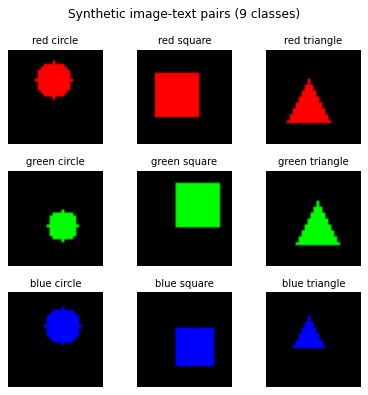

In [1]:
import numpy as np
import matplotlib.pyplot as plt

COLORS = ["red", "green", "blue"]
SHAPES = ["circle", "square", "triangle"]
COLOR_RGB = {"red": [1, 0, 0], "green": [0, 1, 0], "blue": [0, 0, 1]}


def make_image(color, shape, size=32, rng=np.random):
    """画一个 size×size 的彩色形状，位置随机"""
    img = np.zeros((size, size, 3), dtype=np.float32)
    cx = rng.randint(10, size - 10)
    cy = rng.randint(10, size - 10)
    r = rng.randint(5, 8)
    yy, xx = np.mgrid[0:size, 0:size]
    if shape == "circle":
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r
    elif shape == "square":
        mask = (np.abs(xx - cx) <= r) & (np.abs(yy - cy) <= r)
    else:  # triangle：顶点在上，底边在下
        frac = (yy - (cy - r)) / (2 * r)          # 0 在顶，1 在底
        mask = (yy >= cy - r) & (yy <= cy + r) & (np.abs(xx - cx) <= r * frac)
    img[mask] = COLOR_RGB[color]
    return img


# 文本词表：颜色 + 形状 + <pad>
TOK = {w: i for i, w in enumerate(COLORS + SHAPES)}
PAD = len(TOK)
VOCAB = len(TOK) + 1


def make_text(color, shape):
    """token 序列 [color, shape]，pad 到长度 4"""
    ids = [TOK[color], TOK[shape]]
    return ids + [PAD] * (4 - len(ids))


# 看 9 个类各长什么样
rng = np.random.RandomState(0)
fig, axes = plt.subplots(3, 3, figsize=(5, 5))
for i, c in enumerate(COLORS):
    for j, s in enumerate(SHAPES):
        axes[i, j].imshow(make_image(c, s, rng=rng))
        axes[i, j].set_title(f"{c} {s}", fontsize=9)
        axes[i, j].axis("off")
plt.suptitle("Synthetic image-text pairs (9 classes)", fontsize=11)
plt.tight_layout()
plt.show()
print(f"词表: {list(TOK.keys())} + <pad>，共 {VOCAB} 个 token")
print("文本编码示例：'red circle' →", make_text("red", "circle"))

### 11.3 双塔编码器

CLIP 是「双塔」结构：图像走图像编码器、文本走文本编码器，各自输出一个向量，再投影到**同一个** $d$ 维空间。图像编码器用一个小 CNN（真实 CLIP 用 ViT），文本编码器用 embedding + 平均池化（真实 CLIP 用 Transformer）。

两个塔互不通信——它们只能通过 InfoNCE loss 间接被拉到一起。这正是「对比学习」的妙处：不需要标注每一对的具体关系，只要知道「谁和谁配对」。

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)
torch.set_num_threads(4)


class ImageEncoder(nn.Module):
    """小 CNN：图片 → d 维向量"""
    def __init__(self, d=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32→16
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16→8
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8→4
        )
        self.out = nn.Linear(32 * 4 * 4, d)

    def forward(self, x):                 # x: [B, 3, 32, 32]
        return self.out(self.net(x).flatten(1))


class TextEncoder(nn.Module):
    """embedding + 平均池化 → d 维向量"""
    def __init__(self, d=32):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, 16)
        self.out = nn.Linear(16, d)

    def forward(self, ids):               # ids: [B, 4]
        return self.out(self.emb(ids).mean(dim=1))


img_enc = ImageEncoder()
txt_enc = TextEncoder()
n_params = sum(p.numel() for p in img_enc.parameters()) \
         + sum(p.numel() for p in txt_enc.parameters())
print(f"双塔总参数量: {n_params:,}")

双塔总参数量: 31,408


### 11.4 训练：InfoNCE 让匹配对靠近

每一步采一批图文对，算两两相似度，对角线是正确配对，InfoNCE 把对角线概率推大。温度 $\tau=0.07$（CLIP 默认量级）。

In [1]:
import torch.nn.functional as F


def info_nce(img_emb, txt_emb, temp=0.07):
    """对称 InfoNCE：图像→文本 + 文本→图像，取平均"""
    img_emb = F.normalize(img_emb, dim=-1)          # 单位向量，内积 = 余弦
    txt_emb = F.normalize(txt_emb, dim=-1)
    logits = img_emb @ txt_emb.t() / temp           # [B, B]
    targets = torch.arange(logits.size(0))
    loss_i2t = F.cross_entropy(logits, targets)     # 每张图找它的描述
    loss_t2i = F.cross_entropy(logits.t(), targets)  # 每句描述找它的图
    return (loss_i2t + loss_t2i) / 2


def make_batch(B, rng):
    pairs = [(rng.choice(COLORS), rng.choice(SHAPES)) for _ in range(B)]
    imgs = np.stack([make_image(c, s, rng=rng) for c, s in pairs])
    imgs = torch.tensor(imgs).permute(0, 3, 1, 2)            # [B,3,32,32]
    ids = torch.tensor([make_text(c, s) for c, s in pairs])  # [B,4]
    return imgs, ids


opt = torch.optim.AdamW(
    list(img_enc.parameters()) + list(txt_enc.parameters()), lr=3e-3)

rng = np.random.RandomState(0)
print("=== CLIP 训练 ===")
history = []
for step in range(300):
    imgs, ids = make_batch(18, rng)
    loss = info_nce(img_enc(imgs), txt_enc(ids))
    opt.zero_grad()
    loss.backward()
    opt.step()
    history.append(loss.item())
    if step % 60 == 0 or step == 299:
        print(f"  step {step:3d}  loss {loss.item():.4f}")

print("\n关键观察：loss 从 ~3.2 降到 ~1。没到 0 是因为 batch 里偶尔有同类对")
print("（两个'红圆'互相当负样本），这正是 CLIP 要大 batch 的原因。")

=== CLIP 训练 ===
  step   0  loss 3.1248
  step  60  loss 1.3018
  step 120  loss 0.8159
  step 180  loss 1.1220
  step 240  loss 1.1723
  step 299  loss 0.9134

关键观察：loss 从 ~3.2 降到 ~1。没到 0 是因为 batch 里偶尔有同类对
（两个'红圆'互相当负样本），这正是 CLIP 要大 batch 的原因。


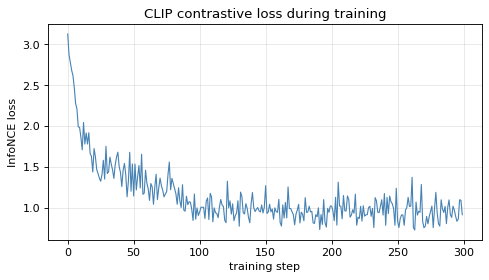

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.plot(history, color="steelblue", linewidth=1)
plt.xlabel("training step")
plt.ylabel("InfoNCE loss")
plt.title("CLIP contrastive loss during training")
plt.grid(True, alpha=0.3)
plt.show()

### 11.5 对齐涌现：拿一句话检索一张图

CLIP 训练得好不好，最直接的检验是**跨模态检索**：给一句话，在一堆图里找出最匹配的那张。如果两个塔真的对齐了，图像向量和文本向量在同一空间里就近邻。下面拿训练好的编码器做图文检索。

In [1]:
@torch.no_grad()
def retrieval_accuracy(n_queries=100):
    """随机生成一张图，从 9 个类的描述里检索，看能不能命中正确类"""
    rng = np.random.RandomState(123)
    correct = 0
    # 9 个类的候选文本
    cand_ids = torch.tensor([make_text(c, s) for c in COLORS for s in SHAPES])
    cand_emb = F.normalize(txt_enc(cand_ids), dim=-1)     # [9, d]
    for _ in range(n_queries):
        c = rng.choice(COLORS)
        s = rng.choice(SHAPES)
        q_img = torch.tensor(make_image(c, s, rng=rng)).permute(2, 0, 1).unsqueeze(0)
        q_emb = F.normalize(img_enc(q_img), dim=-1)       # [1, d]
        hit = (q_emb @ cand_emb.t()).argmax().item()      # 最相似的描述
        true = COLORS.index(c) * len(SHAPES) + SHAPES.index(s)
        correct += int(hit == true)
    return correct / n_queries


acc = retrieval_accuracy(100)
print(f"图文检索准确率: {acc*100:.0f}%   (随机基线 {100/9:.0f}%)")
print("\n关键观察：没标注过任何'这张图对应这句话'，")
print("  只靠对比学习，两个塔就被拉进了同一个空间——给描述能找到图。")
print("  这就是 VLM 视觉前端的由来：CLIP 训出的图像编码器负责'看懂图'。")

图文检索准确率: 100%   (随机基线 11%)

关键观察：没标注过任何'这张图对应这句话'，
  只靠对比学习，两个塔就被拉进了同一个空间——给描述能找到图。
  这就是 VLM 视觉前端的由来：CLIP 训出的图像编码器负责'看懂图'。


### 11.6 CLIP 和前面的 VLM 是什么关系

把这一节和前面几节连起来，VLM 的全貌就清楚了：

- **CLIP（这一节）** 训出图像编码器和文本编码器，让两个空间对齐——解决「视觉特征往哪翻译」的问题
- **PatchEmbedding / ViT** 是 CLIP 图像编码器的内部结构（第 3 节的 PatchEmbedding 是它的第一层）
- **Projector（第 5 节）** 把 CLIP 图像特征翻译进 LLM 的词向量空间
- **LLM** 拿到视觉 token 后，和文本 token 一起走自注意力（MiniVLM，第 10 节）

LLaVA、Qwen-VL 这类主流 VLM，视觉前端几乎都用预训练好的 CLIP ViT——因为对比学习已经让它的图像特征「自带语义」。VLM 的训练通常分两步：先冻结 CLIP 和 LLM、只训 Projector 对齐两边的空间；再解冻少量参数做指令微调（第 8 节讲的冻结策略就是这个意思）。

真实 CLIP 和这里的玩具版差在尺度：4 亿图文对、ViT-Large 编码器、batch 32k——但对齐机制（InfoNCE）和这一节跑的完全一样。

## 小结

这一节你应该抓住这几个点：

- VLM 的定义：同时处理图片和文字，并用语言输出结果的模型。
- 对 decoder-only LLM 接图像的常见路线来说，图片通常要先编码成一串连续向量，再作为 visual tokens 接入语言模型；也有 cross-attention、Q-Former、统一多模态 token 等其他路线。
- Patchify 可以把 224 x 224 图片切成 196 个 16 x 16 patch；16 x 16 是 ViT 里的经典选择之一，实际模型也常用 14、16、32 或动态切图。
- Patch Embedding 把每个 patch 变成 `d_model` 维向量。
- Visual Token 方案把视觉 token 和文本 token 直接拼接，LLM 主体不用改。
- Cross-Attention 不把视觉 token 直接拼进文本主序列，因此不会像 Visual Token 那样直接拉长 self-attention 序列；但仍会增加 cross-attention 计算和视觉特征缓存。
- Projector 是“视觉空间 -> LLM 空间”的翻译器。
- LLaVA 风格路线常用两阶段：先训 Projector 做对齐，再训 Projector + LLM 做指令微调；是否冻结视觉塔和 LLM 要看数据、算力和任务。

| 概念 | 一句话解释 |
|:---|:---|
| Patch | 图片中的一个小块，比如 16 x 16 像素；真实模型的 patch 大小不固定 |
| Patch Embedding | 把 patch 变成向量的层 |
| Visual Token | 图片 patch 对应的 token 向量 |
| Projector | 把视觉特征映射到 LLM embedding 空间 |
| Cross-Attention | Q 来自文本，K/V 来自图像的 attention |
| Q-Former | 用少量 query 把大量视觉特征压缩成少量 token |

**一句话总结**：VLM 不是让 LLM 直接看像素，而是先把图片翻译成一串 embedding，再让 LLM 像读文本一样读这些 embedding。闭源模型如 GPT-4V 没有公开完整视觉架构，所以不能把它当作某条具体开源路线的证据。参考：[ViT 文档](https://huggingface.co/docs/transformers/main/model_doc/vit)、[LLaVA 论文](https://arxiv.org/abs/2304.08485)、[GPT-4V system card](https://cdn.openai.com/papers/GPTV_System_Card.pdf)。

## 作业

做作业时可以问 AI 要思路、拆步骤、检查方向，但不建议直接让 AI 写完答案。

### 作业 1：修改 patch 大小

把 `patch_size` 从 16 改成 32，观察视觉 token 数量如何变化。

小提示：`num_patches = (img_size // patch_size) ** 2`。

```python
patch_emb_32 = PatchEmbedding(img_size=224, patch_size=____, d_model=128)
assert patch_emb_32.num_patches == ____
print("通过：你已经知道 patch 越大，视觉 token 越少。")
```

### 作业 2：实现一个单层 Projector

写一个 `nn.Linear`，把 1024 维视觉特征投影到 4096 维 LLM 空间。

小提示：输入 shape 是 `[2, 196, 1024]`，输出最后一维应该变成 4096。

```python
simple_projector = nn.Linear(____, ____)
x = torch.randn(2, 196, 1024)
y = simple_projector(x)
assert y.shape == (2, 196, 4096)
print("通过：你已经完成了一次视觉空间到语言空间的维度对齐。")
```

### 作业 3：计算两阶段训练比例

假设 Vision Encoder 有 300M 参数，LLM 有 7B 参数，Projector 有 8M 参数。计算阶段 1 和阶段 2 分别有多少参数在训练。

小提示：阶段 1 只训 Projector；阶段 2 训练 Projector + LLM。

```python
vision_params = 300_000_000
llm_params = 7_000_000_000
projector_params = 8_000_000

stage1_trainable = ____
stage2_trainable = ____

assert stage1_trainable == 8_000_000
assert stage2_trainable == 7_008_000_000
print("通过：你已经理解 VLM 为什么要分阶段冻结和训练。")
```


## 参考资料

- Radford et al., [Learning Transferable Visual Models (CLIP)](https://arxiv.org/abs/2103.00020), 2021 — 第 11 节对比学习的来源
- Dosovitskiy et al., [An Image is Worth 16x16 Words (ViT)](https://arxiv.org/abs/2010.11929), 2020 — Vision Transformer
- Liu et al., [Visual Instruction Tuning (LLaVA)](https://arxiv.org/abs/2304.08485), 2023 — CLIP ViT + Projector + LLM 的代表 VLM